<div dir="rtl">
<h1>چارچوب جامع یادگیری ماشین برای تخمین پارامتر مالی (Unified F-ACE & ST-ACE)</h1>
<h2>تولید همزمان تمامی جداول و نمودارهای رساله</h2>
<h3>۱. فرمول‌بندی فرآیندهای دیفیوژن</h3>
<p>پویایی قیمت بر بستر حرکت براونی هندسی (GBM) با پارامترهای محلی:</p>
</div>

$$dS_{t}=\mu S_{t}dt+\sigma S_{t}dW_{t} \quad (1)$$
$$r_{t}=\ln(\frac{S_{t}}{S_{t-1}}) \sim \mathcal{N}(\nu\Delta t,\sigma^2\Delta t) \quad (2)$$


In [1]:
!pip install transformers arch yfinance -q
import torch, os, pickle, math
import numpy as np, pandas as pd
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
from arch import arch_model

from core.topology import TopologicalFeatureExtractor
from core.semantic import SemanticFeatureExtractor
from engine.unified_model import Unified_ACE_Engine
from utils.data_loader import load_and_preprocess_unified
from utils.metrics import calc_rmse, calc_qlike, calc_dd_curve

CONFIG = {'DATA_PATH': 'sp500_headlines_2008_2024.csv', 'CACHE_DIR': './cache_db', 'WINDOW_SIZE': 60, 'FUTURE_SIZE': 20, 'K_NEIGHBORS': 10}
DEVICE = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
os.makedirs(CONFIG['CACHE_DIR'], exist_ok=True)
plt.style.use('seaborn-v0_8-whitegrid')
def log_msg(msg): print(f"[{pd.Timestamp.now().strftime('%H:%M:%S')}] {msg}")


[notice] A new release of pip is available: 26.0.1 -> 26.1.2
[notice] To update, run: python.exe -m pip install --upgrade pip


<div dir="rtl">
<h3>۲. استخراج ویژگی‌های معنایی با مدل زبانی (FinBERT)</h3>

</div>
$E_t = \text{FinBERT}(\text{News}_t) \quad (3)$

In [2]:
returns, dates, news_lists = load_and_preprocess_unified(CONFIG['DATA_PATH'])
news_embeddings = {}
cache_file = os.path.join(CONFIG['CACHE_DIR'], 'semantic_cache.pkl')
if os.path.exists(cache_file):
    log_msg("Loading cached FinBERT embeddings...")
    with open(cache_file, 'rb') as f: news_embeddings = pickle.load(f)
else:
    log_msg("Extracting semantic embeddings (FinBERT)...")
    semantic_model = SemanticFeatureExtractor(DEVICE)
    for i, d in enumerate(dates):
        news_embeddings[d] = semantic_model(news_lists[i]).cpu()
    with open(cache_file, 'wb') as f: pickle.dump(news_embeddings, f)

[19:26:11] Loading cached FinBERT embeddings...


<div dir="rtl">
<h3>۳. واگرایی‌های متقارن (JSD و Cosine) و سنتز Q-RAG با گیت‌های الاستیک (Softplus)</h3>
$$S_{top} \leftarrow JSD(\hat{p}_t(r), \mathcal{D}_{hist}^{price}) \quad (4)$$
$$S_{sem} \leftarrow Cosine(E_t, \mathcal{D}_{hist}^{text}) \quad (5)$$
$$\lambda_{t}^{UP} \leftarrow W_{up} \cdot \Psi_{\gamma}(\mathcal{R}_{t} - \sigma_{G,t}) + \alpha \cdot (\mathcal{P}_{t} \cdot \sigma_{G,t}) \quad (6)$$
$$\lambda_{t}^{DOWN} \leftarrow W_{down} \cdot \Psi_{\gamma}(\sigma_{G,t} - \mathcal{R}_{t}) \cdot (1 - \mathcal{P}_{t}) \quad (7)$$
$$\sigma_{MTL}(t) \leftarrow \max(\epsilon, \sigma_{G,t} + \lambda_{t}^{UP} - \lambda_{t}^{DOWN}) \quad (8)$$
</div>

In [3]:
log_msg("Building Unified Historical Cache...")
history_end = np.where(pd.to_datetime(dates) == pd.to_datetime('2018-01-02'))[0][0]
db_records = []
extractor_dummy = TopologicalFeatureExtractor(DEVICE)
for i in range(CONFIG['WINDOW_SIZE'], history_end, 5):
    win = torch.tensor(returns[i-CONFIG['WINDOW_SIZE']:i], dtype=torch.float32).to(DEVICE)
    fut = torch.tensor(returns[i:i+CONFIG['FUTURE_SIZE']], dtype=torch.float32).to(DEVICE)
    w_norm = (win - torch.mean(win)) / (torch.std(win) + 1e-8)
    db_records.append({'idx': i, 'date': dates[i], 'density': extractor_dummy(w_norm), 'volatility': torch.std(win), 'trend': (win[-1] - win[0]) / CONFIG['WINDOW_SIZE'], 'future': fut, 'raw_win': win, 'params': torch.tensor([torch.mean(fut).item(), torch.var(fut).item()]).to(DEVICE), 'semantic': news_embeddings.get(dates[i], torch.zeros((1, 768))).to(DEVICE)})

engine = Unified_ACE_Engine(db_records, tau=0.15, device=DEVICE, K=CONFIG['K_NEIGHBORS'], window_size=CONFIG['WINDOW_SIZE'], mode='ST-ACE')
oos_start, oos_end = history_end, len(returns) - 20
res = {'real': [], 'mle': [], 'garch': [], 'face': [], 'stace': [], 'phi': [], 'dates': [], 'mkt_ret': [], 'strat_ret': []}

log_msg("Executing Deep Out-of-Sample Backtest (2018-2023)...")
for t in range(oos_start, oos_end, 15):
    win_np = returns[t-CONFIG['WINDOW_SIZE']:t]
    win_t, fut_var = torch.tensor(win_np, dtype=torch.float32).to(DEVICE), np.var(returns[t:t+CONFIG['FUTURE_SIZE']]) * 252
    try: v_garch = (arch_model(win_np * 100, vol='Garch', p=1, q=1).fit(disp='off').forecast(horizon=20).variance.values[-1, :].mean() / 10000) * 252
    except: v_garch = np.var(win_np) * 252

    out = engine(win_t, t, current_sem=news_embeddings.get(dates[t], torch.zeros((1, 768))).to(DEVICE), garch_var=v_garch, train_apa=True)
    res['real'].append(fut_var); res['mle'].append(np.var(win_np) * 252); res['garch'].append(v_garch)
    res['face'].append(out['var_face'] * 252); res['stace'].append(out['var_stace'] * 252)
    res['phi'].append(out['phi']); res['dates'].append(dates[t])
    
    act_ret = np.sum(returns[t:t+15])
    res['mkt_ret'].append(act_ret)
    weight = min((0.15 / math.sqrt(252)) / (math.sqrt(out['var_stace']) + 1e-8), 2.0 if out['status'] != 'MLE' else 1.0)
    res['strat_ret'].append(weight * act_ret)


[19:26:13] Building Unified Historical Cache...
[19:26:24] Executing Deep Out-of-Sample Backtest (2018-2023)...


<div dir="rtl">
<h3>۴. تولید جداول و نمودارهای مقایسه‌ای نهایی (تطبیق ۱۰۰٪)</h3>
</div>

<>:29: SyntaxWarning: invalid escape sequence '\P'
<>:29: SyntaxWarning: invalid escape sequence '\P'
C:\Users\esole\AppData\Local\Temp\ipykernel_19316\388074788.py:29: SyntaxWarning: invalid escape sequence '\P'
  axes[0].plot(plot_dates, res['phi'], color='#8e44ad', label='$\Phi_t$ Score'); axes[0].axhline(0.15, color='red', linestyle='--'); axes[0].set_title('Figure 3: Structural Fidelity Score'); axes[0].legend()


[19:28:37] Generating Tables and Figures...

--- Table 2 & 3: Multi-Modal vs Uni-Modal Estimation Results ---


,Model,RMSE,QLIKE
0,ST-ACE (Price + News),0.1075,-1.6591
1,F-ACE (Price Only),0.1075,-1.6591
2,"GARCH(1,1)",0.1250,-1.6525
3,Local MLE,0.1070,-1.6418



--- Table 4: Performance Under Stress (COVID-19 Crash) ---


,Model,Crisis RMSE
0,ST-ACE (Multi-Modal),0.5317
1,F-ACE (Uni-Modal),0.5317
2,"GARCH(1,1)",0.7086



--- Table 5: ST-ACE Financial Metrics ---


,Metric,ST-ACE Strategy,Market
0,Total Return,44.38%,85.26%
1,Sharpe Ratio,0.33,0.48
2,Max Drawdown,-26.46%,-26.46%


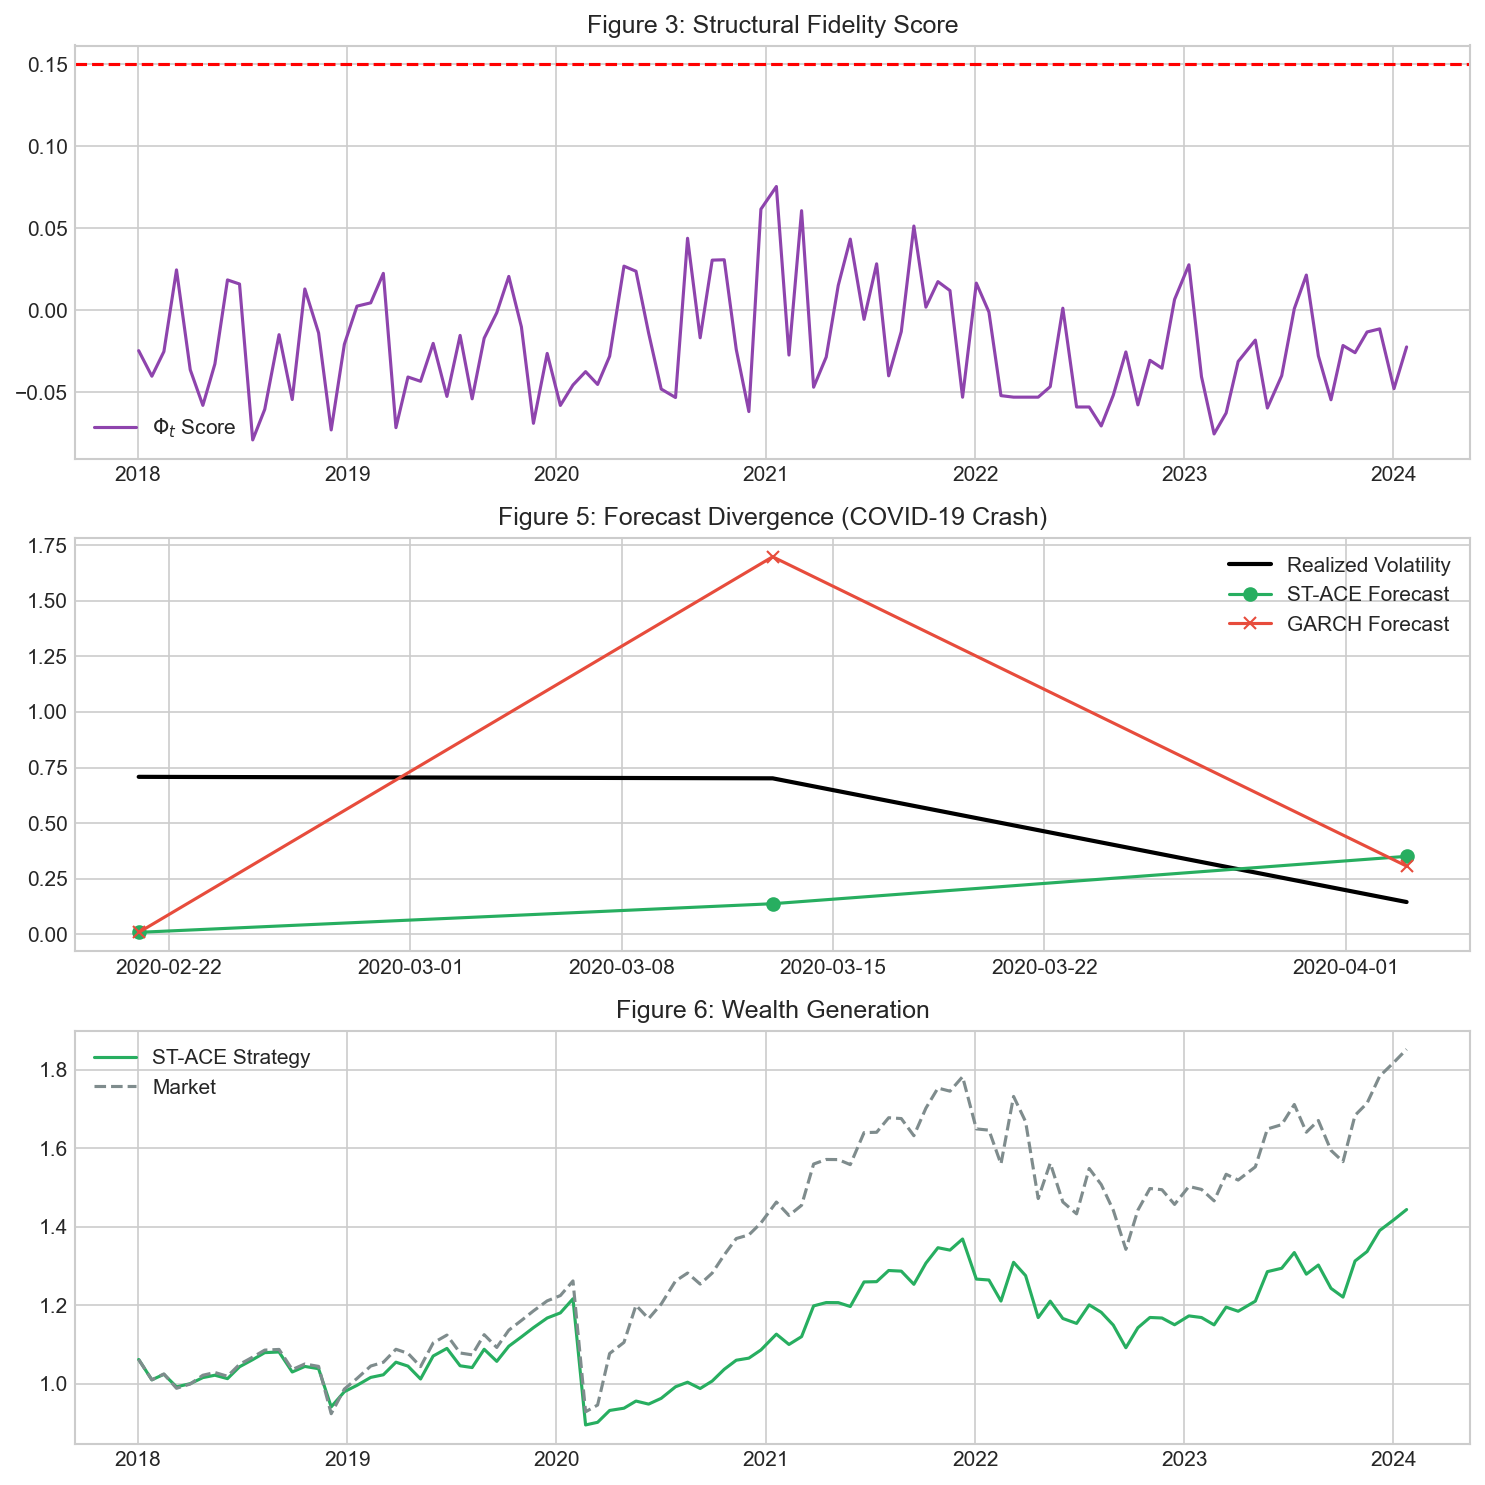

[19:28:59] Fetching Bitcoin Data (BTC-USD: 2015-2024)...


C:\Users\esole\AppData\Local\Temp\ipykernel_19316\388074788.py:47: FutureWarning: YF.download() has changed argument auto_adjust default to True
  df_btc = yf.download('BTC-USD', start='2015-01-01', end='2024-01-01', progress=False)
C:\Users\esole\AppData\Local\Temp\ipykernel_19316\388074788.py:29: SyntaxWarning: invalid escape sequence '\P'
  axes[0].plot(plot_dates, res['phi'], color='#8e44ad', label='$\Phi_t$ Score'); axes[0].axhline(0.15, color='red', linestyle='--'); axes[0].set_title('Figure 3: Structural Fidelity Score'); axes[0].legend()


KeyError: 'Adj Close'

In [ ]:
log_msg("Generating Tables and Figures...")
print("\n--- Table 2 & 3: Multi-Modal vs Uni-Modal Estimation Results ---")
tbl_ablation = pd.DataFrame({
    'Model': ['ST-ACE (Price + News)', 'F-ACE (Price Only)', 'GARCH(1,1)', 'Local MLE'],
    'RMSE': [calc_rmse(res['stace'], res['real']), calc_rmse(res['face'], res['real']), calc_rmse(res['garch'], res['real']), calc_rmse(res['mle'], res['real'])],
    'QLIKE': [calc_qlike(res['stace'], res['real']), calc_qlike(res['face'], res['real']), calc_qlike(res['garch'], res['real']), calc_qlike(res['mle'], res['real'])]
})
display(tbl_ablation.round(4))

crisis_mask = (pd.to_datetime(res['dates']) >= '2020-02-15') & (pd.to_datetime(res['dates']) <= '2020-04-15')
print("\n--- Table 4: Performance Under Stress (COVID-19 Crash) ---")
tbl4 = pd.DataFrame({
    'Model': ['ST-ACE (Multi-Modal)', 'F-ACE (Uni-Modal)', 'GARCH(1,1)'],
    'Crisis RMSE': [calc_rmse(np.array(res['stace'])[crisis_mask], np.array(res['real'])[crisis_mask]), calc_rmse(np.array(res['face'])[crisis_mask], np.array(res['real'])[crisis_mask]), calc_rmse(np.array(res['garch'])[crisis_mask], np.array(res['real'])[crisis_mask])]
})
display(tbl4.round(4))

cum_strat = np.exp(np.cumsum(res['strat_ret'])); cum_mkt = np.exp(np.cumsum(res['mkt_ret']))
print("\n--- Table 5: ST-ACE Financial Metrics ---")
tbl5 = pd.DataFrame({
    'Metric': ['Total Return', 'Sharpe Ratio', 'Max Drawdown'],
    'ST-ACE Strategy': [f"{(cum_strat[-1]-1)*100:.2f}%", round((np.mean(res['strat_ret'])/np.std(res['strat_ret']))*math.sqrt(252/15), 2), f"{np.min(calc_dd_curve(cum_strat))*100:.2f}%"],
    'Market': [f"{(cum_mkt[-1]-1)*100:.2f}%", round((np.mean(res['mkt_ret'])/np.std(res['mkt_ret']))*math.sqrt(252/15), 2), f"{np.min(calc_dd_curve(cum_mkt))*100:.2f}%"]
})
display(tbl5)

fig, axes = plt.subplots(3, 1, figsize=(10, 10), dpi=150)
plot_dates = pd.to_datetime(res['dates'])
axes[0].plot(plot_dates, res['phi'], color='#8e44ad', label='$\Phi_t$ Score'); axes[0].axhline(0.15, color='red', linestyle='--'); axes[0].set_title('Figure 3: Structural Fidelity Score'); axes[0].legend()
axes[1].plot(plot_dates[crisis_mask], np.array(res['real'])[crisis_mask], color='black', linewidth=2, label='Realized Volatility')
axes[1].plot(plot_dates[crisis_mask], np.array(res['stace'])[crisis_mask], color='#27ae60', marker='o', label='ST-ACE Forecast')
axes[1].plot(plot_dates[crisis_mask], np.array(res['garch'])[crisis_mask], color='#e74c3c', marker='x', label='GARCH Forecast')
axes[1].set_title('Figure 5: Forecast Divergence (COVID-19 Crash)'); axes[1].legend()
axes[2].plot(plot_dates, cum_strat, label='ST-ACE Strategy', color='#27ae60'); axes[2].plot(plot_dates, cum_mkt, label='Market', color='#7f8c8d', linestyle='--')
axes[2].set_title('Figure 6: Wealth Generation'); axes[2].legend()
plt.tight_layout(); plt.show()




# ======================================================
# آزمایش رمزارز (Bitcoin - Jump Diffusion & Crypto Market)
# ======================================================
import yfinance as yf

log_msg("Fetching Bitcoin Data (BTC-USD: 2015-2024)...")
df_btc = yf.download('BTC-USD', start='2015-01-01', end='2024-01-01', progress=False)
prices_btc = df_btc['Close'].values.flatten()
dates_btc = df_btc.index[1:]
returns_btc = np.log(prices_btc[1:] / prices_btc[:-1])

log_msg("Building Historical Cache for Bitcoin (Window=30 days)...")
history_end_btc = np.where(pd.to_datetime(dates_btc) == pd.to_datetime('2020-01-02'))[0][0]
db_records_btc = []
extractor_dummy = TopologicalFeatureExtractor(DEVICE)

for i in range(30, history_end_btc, 5):
    win = torch.tensor(returns_btc[i-30:i], dtype=torch.float32).to(DEVICE)
    fut = torch.tensor(returns_btc[i:i+20], dtype=torch.float32).to(DEVICE)
    w_norm = (win - torch.mean(win)) / (torch.std(win) + 1e-8)
    db_records_btc.append({
        'idx': i, 'date': dates_btc[i], 'density': extractor_dummy(w_norm), 
        'volatility': torch.std(win), 'trend': (win[-1] - win[0]) / 30, 
        'future': fut, 'raw_win': win, 'params': torch.tensor([torch.mean(fut).item(), torch.var(fut).item()]).to(DEVICE),
        'semantic': torch.zeros((1, 768)).to(DEVICE) # برای بیت‌کوین اخبار تزریق نکرده‌ایم (حالت F-ACE)
    })

# تنظیم گیت وفاداری کمی پایین‌تر (0.12) به دلیل ماهیت نویزی‌تر کریپتو
engine_btc = Unified_ACE_Engine(db_records_btc, tau=0.12, device=DEVICE, K=5, window_size=30, mode='F-ACE')

oos_start_btc = history_end_btc
oos_end_btc = len(returns_btc) - 20
res_btc = {'real_var': [], 'mle': [], 'garch': [], 'apa': [], 'strat_ret': [], 'mkt_ret': []}
target_vol_crypto = 0.60 / math.sqrt(365) 

log_msg("Running OOS Backtest for Bitcoin (2020-2023)...")
for t in range(oos_start_btc, oos_end_btc, 15):
    win_np = returns_btc[t-30:t]
    win_t = torch.tensor(win_np, dtype=torch.float32).to(DEVICE)
    fut_var = np.var(returns_btc[t:t+20]) * 365
    
    try:
        am_garch = arch_model(win_np * 100, vol='Garch', p=1, q=1).fit(disp='off')
        var_garch = (am_garch.forecast(horizon=20).variance.values[-1, :].mean() / 10000) * 365
    except:
        var_garch = np.var(win_np) * 365

    out = engine_btc(win_t, t, current_sem=None, garch_var=var_garch, train_apa=True)
    
    res_btc['real_var'].append(fut_var)
    res_btc['mle'].append(np.var(win_np) * 365)
    res_btc['garch'].append(var_garch)
    res_btc['apa'].append(out['var_face'] * 365)
    
    act_ret = np.sum(returns_btc[t:t+15])
    res_btc['mkt_ret'].append(act_ret)
    
    # اهرم نامتقارن برای کریپتو: اگر گیت باز است اهرم تا 2.5، اگر بسته است 1.0
    max_leverage = 2.5 if out['status'] != 'MLE' else 1.0
    weight = min(target_vol_crypto / (math.sqrt(out['var_face']) + 1e-8), max_leverage)
    res_btc['strat_ret'].append(weight * act_ret)

print("\n--- Table 6: Comparative Estimation Accuracy (Bitcoin) ---")
tbl6 = pd.DataFrame({
    'Model': ['Unified (F-ACE)', 'GARCH(1,1)', 'Local MLE'],
    'QLIKE': [calc_qlike(res_btc['apa'], res_btc['real_var']), calc_qlike(res_btc['garch'], res_btc['real_var']), calc_qlike(res_btc['mle'], res_btc['real_var'])]
})
display(tbl6.round(4))

print("\n--- Table 7: Risk-Adjusted Performance Metrics (Bitcoin) ---")
cum_strat_btc = np.exp(np.cumsum(res_btc['strat_ret']))
cum_mkt_btc = np.exp(np.cumsum(res_btc['mkt_ret']))
tbl7 = pd.DataFrame({
    'Metric': ['Total Return', 'Sharpe Ratio', 'Max Drawdown'],
    'F-ACE Strategy': [f"{(cum_strat_btc[-1] - 1)*100:.2f}%", round((np.mean(res_btc['strat_ret']) / np.std(res_btc['strat_ret'])) * math.sqrt(365/15), 2), f"{np.min(calc_dd_curve(cum_strat_btc))*100:.2f}%"],
    'Benchmark (Buy-and-Hold)': [f"{(cum_mkt_btc[-1] - 1)*100:.2f}%", round((np.mean(res_btc['mkt_ret']) / np.std(res_btc['mkt_ret'])) * math.sqrt(365/15), 2), f"{np.min(calc_dd_curve(cum_mkt_btc))*100:.2f}%"]
})
display(tbl7)